**<h1>DSCI 100 Final Project**</h1>
<h3>Section 008 Group 19</h3>
<h5>Name: Camille S, Chloe Lin, Erica, Seerat Waraich</h5>

<h2>Introduction:</h2>
Understanding what motivates players to engage more deeply with a game is an important area of study in game analytics and player-behaviour research. One meaningful indicator of engagement is whether a player chooses to subscribe to a game-related newsletter. Newsletter subscriptions are valuable to game developers because they signal higher investment, allow for targeted communication, and help sustain an active player community. Identifying the characteristics that predict whether a player will subscribe can guide marketing strategies and improve player retention.
<p></p>
<h4>Broad Question:</h4>
<p>
What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?
<p></p>
To investigate this further, our project focuses on a more precise analytical question:
<p>
Can age and total playtime help predict whether a player subscribes to the newsletter?
<p></p>
This specific question allows us to test if the time spent in-game and a player's age have meaningful relationships with subscription status, which allows us to predict subscription behaviour.

<h2>Method & Results:</h2>
<h3>1. Load Data</h3>

In [2]:
#cell for loading packages
library(tidyverse)
library(tidymodels)
library(repr)
library(ggplot2)
library(themis)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

In [3]:
url <- "https://raw.githubusercontent.com/camillesnyder/Final-Project/refs/heads/main/players.csv"
download.file( url, destfile = "players.csv")
players_data <- read_csv("players.csv")

head(players_data)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


<h3>2. Data Cleaning and Wrangling</h3>

In [4]:
#wrangling data by changing subscribe to a factor vector 
#selecting played_hours vector and Age vector as predictors, and subscribe variable as the response
#filtering out NA values so they doesn't mess up calculations
players_wrang <- players_data|>
    select(played_hours, Age, subscribe)|>
    mutate(subscribe = as_factor(subscribe))|>
    drop_na()

### 3. Data Summary

#### players_data:

In [5]:
summary(players_data)

  experience        subscribe       hashedEmail         played_hours    
 Length:196         Mode :logical   Length:196         Min.   :  0.000  
 Class :character   FALSE:52        Class :character   1st Qu.:  0.000  
 Mode  :character   TRUE :144       Mode  :character   Median :  0.100  
                                                       Mean   :  5.846  
                                                       3rd Qu.:  0.600  
                                                       Max.   :223.100  
                                                                        
     name              gender               Age       
 Length:196         Length:196         Min.   : 9.00  
 Class :character   Class :character   1st Qu.:17.00  
 Mode  :character   Mode  :character   Median :19.00  
                                       Mean   :21.14  
                                       3rd Qu.:22.75  
                                       Max.   :58.00  
                               

|           |          |          |
| :-------- | :------- | :------- |
| **experience**  | character | players' experience levels in-game classified into levels: “Amateur”, “Beginner”, “Pro”, “Regular”, “Veteran” |
| **subscribe** |logical |  whether players subscribe to a game-related newsletter, indicated with TRUE and FALSE     |
| **hashedEmail**    |character | players’ email address    |
| **played_hours**      |numerical | players’ total play time (in hours) |
| **name**              |character |players' names|
| **gender**            |character | players' gender |
| **Age**               |numerical | players' age|

#### Players' Subscription Counts

In [6]:
players_data |> count(subscribe)

subscribe,n
<lgl>,<int>
FALSE,52
TRUE,144


Above shows the number of players who subscribed to the game-related newsletter and those who did not. There are more subscribers than non-subscribers in this dataset, which means the classes are not perfectly balanced. It is important to keep in mind when using it as a response variable in modeling, because unequal class sizes may influence the accuracy of our classifier.

#### Players' Experience Levels Counts

In [7]:
players_data |> count(experience)

experience,n
<chr>,<int>
Amateur,63
Beginner,35
Pro,14
Regular,36
Veteran,48


Above shows the number of players of each experience level in-game.

#### Subscription Rate of Players

In [8]:
# Subscription Rate of players
proportion_of_subscribed <- players_data|>
    summarize(proportion_subscribed = sum(subscribe == "TRUE")/196)

proportion_of_subscribed

proportion_subscribed
<dbl>
0.7346939


#### Mean of [Age] & [subscribe]

In [9]:
# Mean of [Age] & [subscribe]
player_avgs <- players_wrang|>
    summarize(mean_played_hrs = mean(played_hours),
             mean_age = mean(Age, na.rm = TRUE))

player_avgs

mean_played_hrs,mean_age
<dbl>,<dbl>
5.904639,21.13918


### 4. Visualization of the Dataset
In this section, we explore the variables that may relate to newsletter subscription, including basic summaries and visualizations.

#### Fig. 1 - Subscription Rates by Experience Level

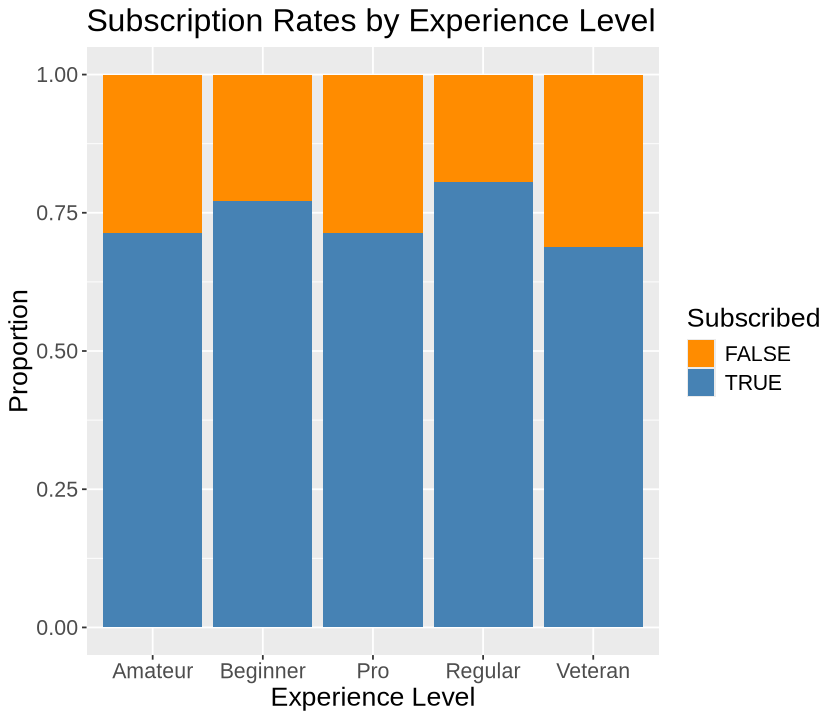

In [10]:
players_data |>
  ggplot(aes(x = experience, fill = subscribe)) +
  geom_bar(position = "fill") +
  labs(title = "Subscription Rates by Experience Level",
       x = "Experience Level",
       y = "Proportion",
       fill = "Subscribed") +
     scale_fill_manual(values = c("darkorange", "steelblue"))+
    theme(text = element_text(size = 16))

This graph shows us that subscription rates are generally the same for every experience level, and not increasing or decreasing with more or less experience. Experience would not be a good predictor because it doesn't have a relationship with subscription.

#### Fig. 2 - Subscription Rates by Age

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_count()`).”


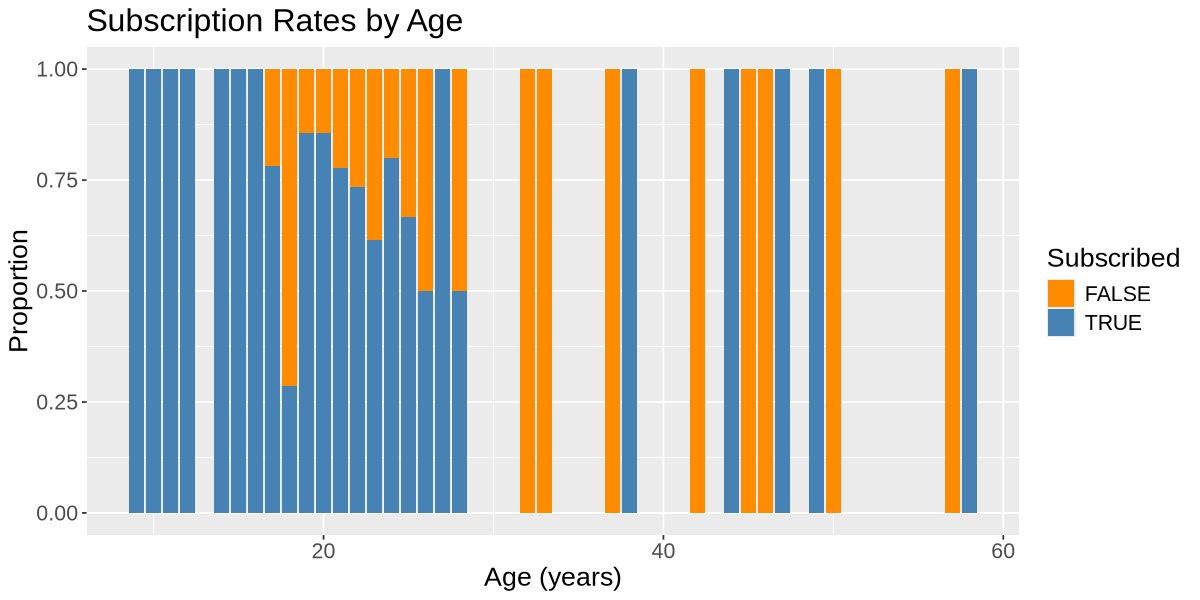

In [11]:
options(repr.plot.height = 5, repr.plot.width = 10)
players_data |>
  ggplot(aes(x = Age, fill = subscribe)) +
  geom_bar(position = "fill") +
  labs(title = "Subscription Rates by Age",
       x = "Age (years)",
       y = "Proportion",
       fill = "Subscribed") +
     scale_fill_manual(values = c("darkorange", "steelblue"))+
    theme(text = element_text(size = 16))

Above graph shows as age increases gradually, the chance of players subscribing to the game-related newsletter decreases.

#### Fig. 3 - Subscription Rates by Total Amount of Played Hours

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 85 rows containing non-finite outside the scale range (`stat_count()`).”
Warning message:
“`position_stack()` requires non-overlapping x intervals.”


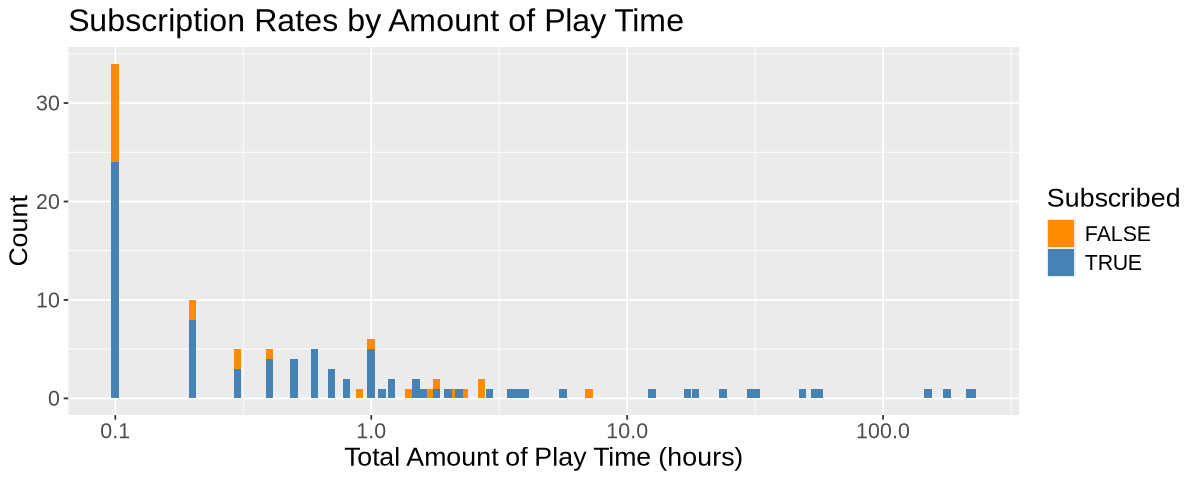

In [12]:
options(repr.plot.height = 4, repr.plot.width = 10)
players_data |>
  ggplot(aes(x = played_hours, fill = subscribe)) +
  geom_bar(width= 0.03) +
  labs(title = "Subscription Rates by Amount of Play Time",
       x = "Total Amount of Play Time (hours)",
       y = "Count",
       fill = "Subscribed") +
    scale_x_log10()+
     scale_fill_manual(values = c("darkorange", "steelblue"))+
    theme(text = element_text(size = 16))

Above graph shows a player is more likely to be subscribed to game-related newsletters when the total amount of play time increases.

#### Fig. 4 - Age of Player versus Total Play Time Color Coded by Subscription

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


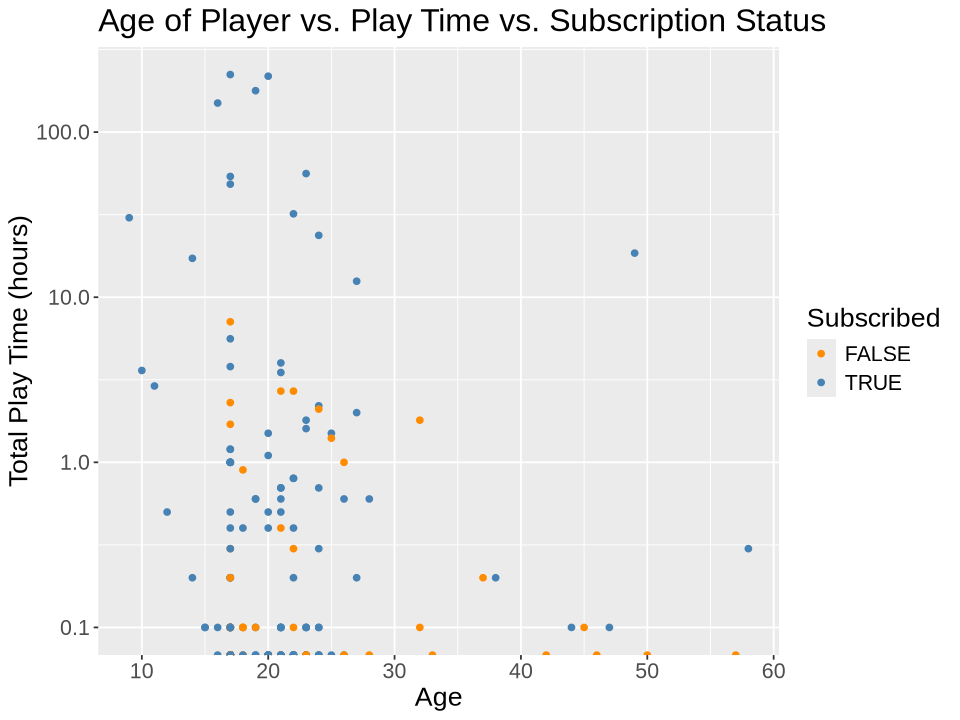

In [13]:
options(repr.plot.width = 8, repr.plot.height = 6)
players_data|>
    ggplot( aes(x = Age, y = played_hours, color = subscribe))+
    geom_point()+
    labs(x = "Age",
         y = "Total Play Time (hours)",
         color = "Subscribed",
         title = "Age of Player vs. Play Time vs. Subscription Status")+
    scale_y_log10()+
     scale_color_manual(values = c("darkorange", "steelblue"))+
    theme(text = element_text(size = 16))

This graph summarizes the variables of Age and Total Play Time in the same graph with color coding by subscription to differentiate players who have subscribed game-related newsletters.

#### Fig. 5 - Subscription Rate by Gender

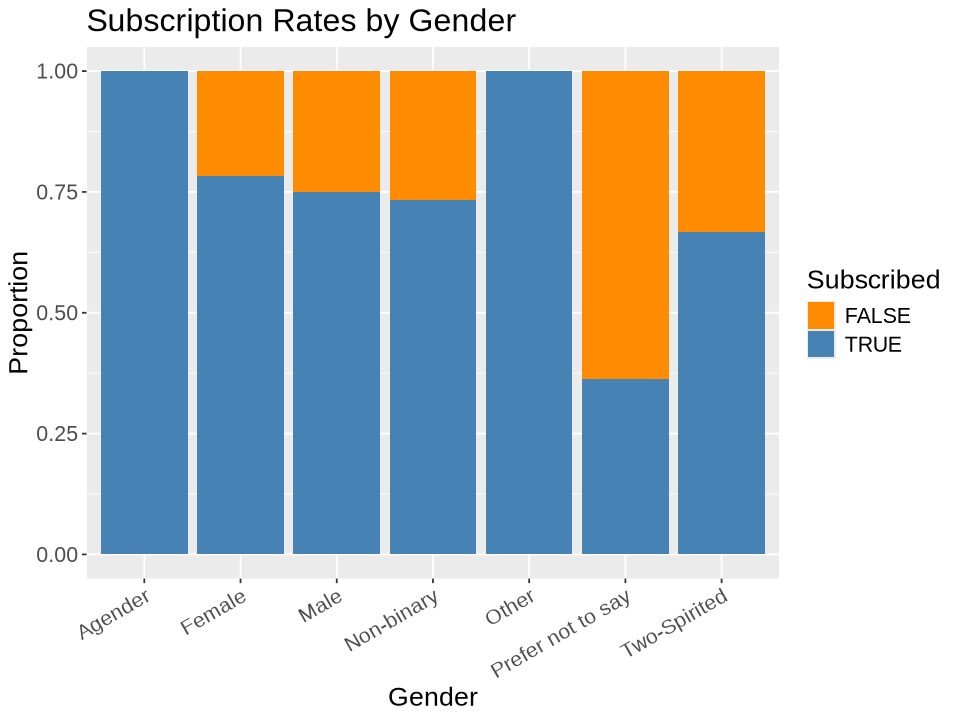

In [14]:
players_data |>
  ggplot(aes(x = gender, fill = subscribe)) +
  geom_bar(position = "fill") +
  labs(title = "Subscription Rates by Gender",
       x = "Gender",
       y = "Proportion",
       fill = "Subscribed") +
    scale_fill_manual(values = c("darkorange", "steelblue"))+
    theme(text = element_text(size = 16), axis.text.x = element_text(angle = 30, vjust = 1, hjust=1))
#rotate labels eventually

#### Fig. 6 - Subscription Count by Gender

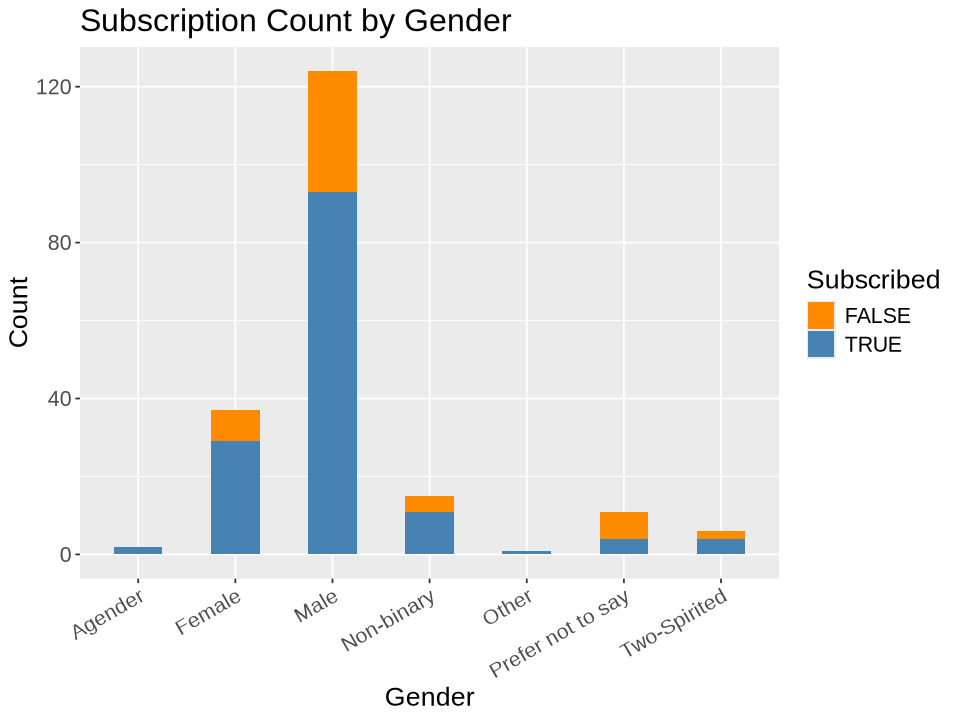

In [15]:
players_data |>
  ggplot(aes(x = gender, fill = subscribe)) +
  geom_bar(width= 0.5) +
  labs(title = "Subscription Count by Gender",
       x = "Gender",
       y = "Count",
       fill = "Subscribed") +
     scale_fill_manual(values = c("darkorange", "steelblue"))+
    theme(text = element_text(size = 16), axis.text.x = element_text(angle = 30, vjust = 1, hjust=1))

There is no obvious relationship between a player's gender and their subscription status, which makes gender a bad predictor for subscription status.

### 5. Exploratory Data Analysis (EDA)

Below we are performing prediction with KNN-Classification method, because our response variable is a logical variable. Response variable is [subscribe], the logical value can be categorized and converted into factor type; the explanatory variables [Age] & [played_hours] are numeric and continuous, which can work with the euclidean distance calculation method in KNN to measure the distance between 2 observations.

In [16]:
#train on 75% and test on 25% of the data
set.seed(27)

players_split <- players_wrang|>
    initial_split( prop = 0.75, strata = subscribe)

players_train <- training(players_split)

players_test<- testing(players_split)

#model specification
knn_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = tune())|>
            set_engine("kknn")|>
            set_mode("classification")
#possible parameter values
k_vals<- tibble(neighbors = seq(from = 1, to = 40, by = 2))

#recipe to standardize data so all factors contribute equally to distance calculation
players_recipe <- recipe(subscribe ~ played_hours + Age, data = players_train)|>
      step_normalize(all_predictors())

#validation via subsetting the training data
#validation is performed get an average of accuracies for each number of neighbors
players_vfold <- vfold_cv(players_train, v = 10, strata = subscribe)

#results about how well the model predicts subscription status for each K-value
players_results <- workflow()|>
    add_recipe(players_recipe)|>
    add_model(knn_spec)|>
    tune_grid(resamples = players_vfold, grid = k_vals)|>
    collect_metrics()|>
    filter(.metric == "accuracy")

players_results |>
filter(mean == max(mean))|>
select(neighbors, mean)

neighbors,mean
<dbl>,<dbl>
17,0.7512088


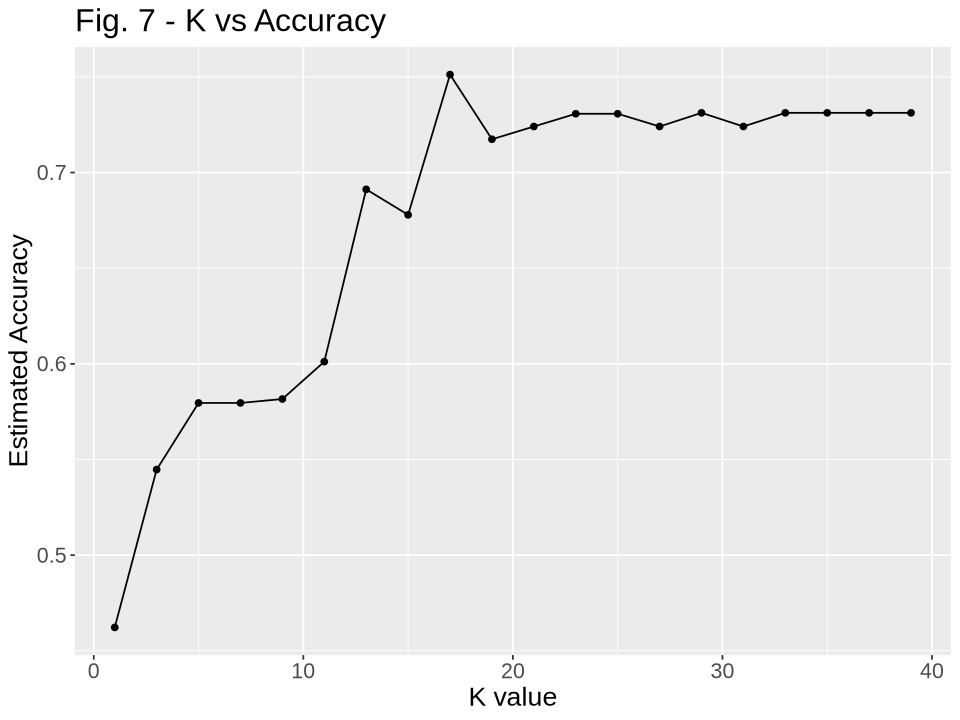

In [17]:
options(repr.plot.height = 6)
K_vs_accuracy <- ggplot(players_results, aes( x= neighbors, y = mean))+
    geom_point()+
    geom_line()+
    labs( x = "K value",
         title = "Fig. 7 - K vs Accuracy",
        y = "Estimated Accuracy")+
    theme(text = element_text(size = 16))

K_vs_accuracy

**K = 17 gives the best accuracy, as it gives the highest estimated accuracy and larger K values will result in a reduced accuracy estimate, so K = 17 is chosen for the final modelling.**

In [18]:
#retrain model based on best parameter value k=17
players_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 17)|>
    set_engine("kknn")|>
    set_mode("classification")

#test new model on test data 
players_fit <- workflow()|>
    add_recipe(players_recipe)|>
    add_model(players_spec)|>
    fit(data = players_train)

test_predictions<- predict(players_fit, players_test)|>
    bind_cols(players_test)|>
    metrics(truth = subscribe, estimate = .pred_class)|>
    filter(.metric == "accuracy")
   
test_predictions|>
mutate(accuracy = .estimate)|>
    select(accuracy)


accuracy
<dbl>
0.7346939


In [19]:
test_predictions<- predict(players_fit, players_test)|>
    bind_cols(players_test)  
#calculates accuracy of model
test_predictions |> metrics(truth = subscribe, estimate = .pred_class) |>
                    filter(.metric == "accuracy")

test_predictions |> pull(subscribe) |> levels()
#calculates precision of model
test_predictions |> precision(truth = subscribe, estimate = .pred_class, event_level = "second")
#calculates recall of model
test_predictions |> recall(truth = subscribe, estimate = .pred_class, event_level = "second")


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.7346939


[1] "FALSE" "TRUE"

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
precision,binary,0.7555556


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
recall,binary,0.9444444


## Discussions

### Initial Data Set Observations and Analysis

##### Fig. 1—Subscription Rates by Experience Level
This chart shows that subscription rates stay almost the same across all five experience groups. In every group, the blue portion (subscribed) is much larger than the orange portion (not subscribed), and the proportions barely change as experience increases. Because there is no upward or downward trend, experience level does not seem to affect whether a user subscribes, meaning it would likely be a weak predictor in a subscription model.
##### Fig. 2—Subscription Rates by Age
This visualization shows the subscription rates change noticeably with age. Younger players have a higher proportion of subscribers (blue), while older players show more non-subscribers (orange). As age increases, the percentage of subscribed users gradually goes down, meaning older users are less likely to subscribe. Because of this clear pattern, age seems to influence subscription rate and could be a useful predictor in a subscription model.

##### Fig 3—Subscription rates by total amount of played hours 
<p>
This chart shows that players with very low playtime have a mix of subscribers and non-subscribers, but as total playtime increases, subscribed players become much more common. The longer someone has played, the more likely they are to subscribe. Because of this clear upward pattern, total playtime has a strong relationship with subscription and could be a useful predictor in a subscription model.

##### Fig 4 - Age of Player versus Total Play Time Color Coded by Subscription
<p>
This graph shows the relationship between Age and Total Play Time with subscription status indicated with color coding to distinguish players who have subscribed game-related newsletters. The distribution shows the majority of younger players, within the 15-25 age range. The relationship between these variables may have a moderately negative exponential trend, suggesting play time tends to decrease as age increases. Furthermore, the visualization indicates players with higher total play time associated with a higher subscription rate, which implies total play time would be a suitable variable as predictor in the model for further exploration on the question.

##### Fig. 5 - Subscription Rate by Gender & Fig. 6 - Subscription Count by Gender
<p>
Although the subscription rates across genders appear similar in Fig. 5, a closer look of Fig. 6, presented with subscription count shows certain genders are underrepresented while male players contribute the majority of the dataset revealing an imbalance in representatives. Furthermore,no obvious association between gender and subscription status indicates gender is not a reliable predictor for subscription status.
<p></p>

### Assumptions and Limitations
There were several assumptions and limitations built into our analysis that are important to acknowledge. First, our KNN classification model assumes that the chosen variable is an appropriate predictor and that the predictors should be given the same weight, e.g. “voting power”, to classification calculations. Although we normalized predictors to meet this assumption, it is still possible that age and play time do not naturally contribute equally to a player’s ultimate decision of whether to subscribe or not. Another assumption is that our dataset is large enough to be representative of the Minecraft gamer population to capture meaningful variation in subscription behaviour. With only 196 observations, the model may not generalize well to a larger player population. The KNN algorithm itself also poses limitations: it becomes increasingly slow as dataset size grows, performs poorly when classes are imbalanced, and tends to make predictions that mimic the shape and density of the training data rather than capturing deeper relationships.

### Expectations, Findings, Future Questions, and Final Conclusions
Overall, our results showed that age and total play time were the only variables that showed any meaningful relationship with newsletter subscription, while experience level and gender were essentially unrelated to subscription behaviour. Through our visualizations, we saw that players who logged more total hours tended to subscribe at higher rates, and most subscribers clustered in the younger age ranges. When we applied a KNN classifier using age and played hours as predictors, the model achieved an accuracy of about 73%, which at first seems decent but is ultimately no better than a simple majority classifier. Since roughly 74% of players in our dataset were subscribed, a classifier that blindly predicted “subscribed” for everyone would achieve nearly the same accuracy. That contrast makes it clear that even though the predictors show some trends, they are not strong enough to outperform the baseline model.
<p></p>
These findings were somewhat outside of what we expected. One of the biggest surprises was that experience level had absolutely no relationship with subscription status. Intuitively, we thought that newer players might want to subscribe to learn tips or feel more connected to the game community, or that highly experienced players might be motivated to stay engaged with updates and advanced content. Instead, subscription behaviour seems to exist completely independent of how seasoned a player is. It was also unexpected that our model performed no better than a majority classifier, especially since the class imbalance in the subscription variable was not extreme. Usually, KNN should still pick up some meaningful structure even with moderate imbalance. Along the same lines, the recall of our model was surprisingly high (0.94), meaning that it identified almost all of the actual subscribers. This is surprising because models that do not outperform the baseline typically do not show such strong recall. The most likely explanation is that the model leaned heavily into predicting “subscribed” for most cases, which artificially boosts recall without improving overall accuracy. This is not a desirable outcome since the research group wants to know definitively who is most likely to subscribe, which means a model with higher precision than recall is better.
<p></p>
Despite these limitations, the patterns we found still have meaningful implications. The fact that age and total play time were more related to subscription behaviour than experience level suggests that generational attitudes toward newsletters and online game content may play a role. Younger players may be more comfortable with digital subscriptions in general or more eager to stay connected to game communities. Meanwhile, total play time being positively associated with subscription likelihood makes intuitive sense; players who are more invested in the game may naturally seek out more content, updates, and resources. This could be useful for game developers who want to tailor outreach strategies toward groups most likely to engage.
<p></p>
These results also raise several interesting future questions. For example, are there specific age ranges where subscription likelihood spikes, and could this be tied to differences in how each generation was introduced to technology? It might also be worth asking whether older players are less interested in newsletters because of broader attitudes toward gaming or digital communication. Another question is whether the relationship between play time and subscription reflects something deeper about immersion during childhood and adolescence for instance, do players who grew up surrounded by digital media engage more with external game content overall? These potential explanations open the door for further surveys or longitudinal studies.
<p></p>
In summary, our analysis showed that while age and total play time have some relationship with subscription status, they are not strong enough predictors to improve classification accuracy beyond a majority baseline. We were surprised by the lack of impact of experience level, and equally surprised by the model’s high recall despite low improvement in accuracy. These findings highlight the complexity of predicting engagement behaviour and suggest that additional variables, such as motivation, social involvement, or in-game activities may be needed to better understand why players choose to subscribe. Future work could explore these possibilities to develop a more complete picture of subscription behaviour in gaming communities.